# Waste Classifier — Evaluation Notebook

This notebook evaluates the MobileNetV2 waste classifier on the validation set.

> **Fix applied:** The model and class names are loaded from the saved  files produced during training, so class indices are guaranteed to match the training mapping ().

## 1. Imports

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

## 2. Load the Model

Load the saved Keras model.

In [2]:
model = load_model("../model/waste_classifier.keras")
print("Model loaded successfully.")

Model loaded successfully.


In [3]:
# Add this right after loading the model
print(model.summary())

# And check the rescaling — your training notebook had:
# layers.Rescaling(1./255) INSIDE the model
# So input should be raw 0-255 pixels
# Verify by checking what the model's first layers are
for layer in model.layers[:5]:
    print(layer.name, layer.__class__.__name__)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,752,212 (10.50 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 329,486 (1.26 MB)

None
sequential Sequential
rescaling Rescaling
mobilenetv2_1.00_224 Functional
global_average_pooling2d GlobalAveragePooling2D
dense Dense


## 3. Rebuild the Validation Dataset

**Important:** We must use the same , , and  as during training so that the same images land in the validation split and the class indices are identical ( assigns indices alphabetically).

In [4]:
DATASET_PATH = "../dataset"

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,            # same seed as training
    image_size=(224, 224),
    batch_size=32,
)

class_names = val_dataset.class_names
print("Classes:", class_names)
print("Expected: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']")

Found 2525 files belonging to 6 classes.
Using 505 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Expected: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### Sanity check

Verify that the class list matches the training mapping exactly. If it does not, stop here and check that  points to the folder containing all 6 class sub-folders.

In [5]:
expected = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
assert class_names == expected, (
    f"Class mismatch! Got:      {class_names} Expected: {expected}"
)
print("Sanity check passed — class mapping is correct.")

Sanity check passed — class mapping is correct.


## 4. Run Predictions

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
val_dataset_prefetch = val_dataset.prefetch(buffer_size=AUTOTUNE)

predictions = model.predict(val_dataset_prefetch)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.concatenate([
    labels.numpy() for _, labels in val_dataset   # use non-prefetched for labels
])

print(f"Total samples evaluated : {len(true_classes)}")
print(f"Unique true labels      : {np.unique(true_classes)}")
print(f"Unique predicted labels : {np.unique(predicted_classes)}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 513ms/step
Total samples evaluated : 505
Unique true labels      : [0 1 2 3 4 5]
Unique predicted labels : [0 1 2 3 4 5]


## 5. Classification Report

In [7]:
report = classification_report(
    true_classes,
    predicted_classes,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0
)
print(report)

              precision    recall  f1-score   support

   cardboard       0.12      0.12      0.12        69
       glass       0.21      0.18      0.19       102
       metal       0.19      0.22      0.20        87
       paper       0.25      0.24      0.24       123
     plastic       0.18      0.20      0.19        91
       trash       0.15      0.12      0.14        33

    accuracy                           0.19       505
   macro avg       0.18      0.18      0.18       505
weighted avg       0.19      0.19      0.19       505



## 6. Confusion Matrix

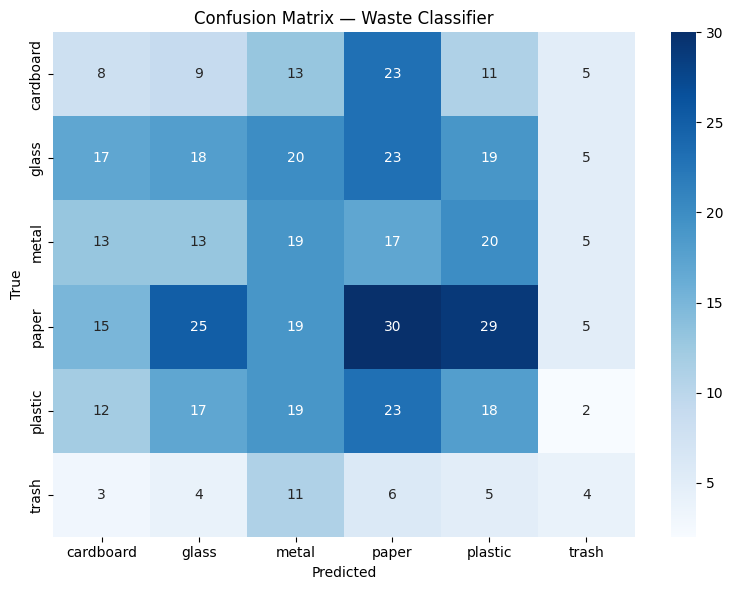

In [8]:
cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(len(class_names))))

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Waste Classifier")
plt.tight_layout()
plt.show()

## 7. Per-class Accuracy Bar Chart

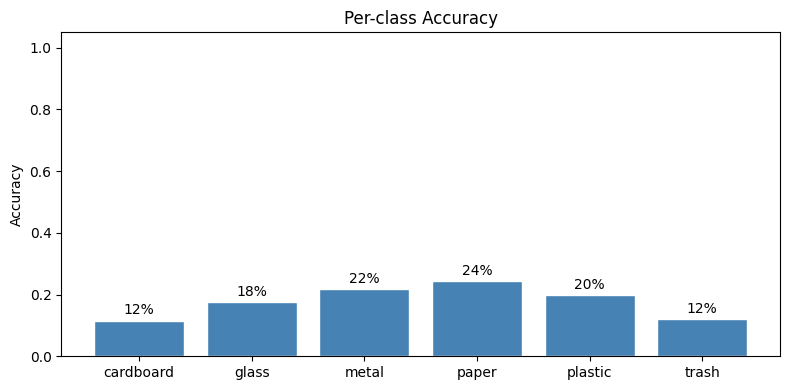

In [9]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8, 4))
bars = plt.bar(class_names, per_class_acc, color="steelblue", edgecolor="white")
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Per-class Accuracy")
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{acc:.0%}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 8. Sample Predictions Grid

Visualise 9 random validation images with their true label, predicted label, and confidence score. **Green** title = correct prediction, **red** = wrong.

In [10]:
plt.figure(figsize=(13, 13))

for images, labels in val_dataset.take(1):
    batch_preds   = model.predict(images)
    pred_labels   = np.argmax(batch_preds, axis=1)
    confidence    = np.max(batch_preds, axis=1) * 100

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        true_label  = class_names[labels[i]]
        pred_label  = class_names[pred_labels[i]]
        correct     = (labels[i] == pred_labels[i])

        color = "green" if correct else "red"
        plt.title(
            f"True : {true_label}
Pred : {pred_label}
{confidence[i]:.1f}%",
            color=color, fontsize=9
        )
        plt.axis("off")

plt.suptitle("Sample Predictions (green = correct, red = wrong)", fontsize=13)
plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 18) (2820395592.py, line 18)

## 9. (Optional) Save Results

Re-save the  files from this corrected run so they stay in sync with the model.

In [ ]:
np.save("../model/true_classes.npy",      true_classes)
np.save("../model/predicted_classes.npy", predicted_classes)
np.save("../model/class_names.npy",       np.array(class_names))
print("Results saved.")